# Does blue ice "blur" its climate record? A walkthrough using the Allan Hills CFA data

**The question.** Tierney & Ibarra argue that the old Allan Hills blue ice has been *mixed* after it formed: gases and water isotopes have smeared out over tens of centimetres. If so, the flat CO₂ record reported by Marks-Peterson et al. could be partly an artefact of that smearing and not a real feature of the ancient atmosphere.

**Their model, in one sentence.** Take the "true" record along the core and blur it, the way you'd blur a photo, by a fixed amount. The amount of blur is a single number, σ (sigma), called the *mixing length*. They never measure σ directly. They pick the value that makes their simulated record about as variable as the real one, and get:

| what's measured | their σ |
|---|---|
| CO₂ (a gas) | **75 cm** |
| δD (water isotopes, part of the ice itself) | **30 cm** |
| ocean temperature from noble gases | 25 cm |

**How we can test that.** The Allan Hills ice is folded, so ice of very different ages often sits right next to other ice, with a sharp boundary between them. We'll call these boundaries **contacts**. In a photo, blur is easiest to judge at sharp edges. If the ice were blurred by 30 cm, *every* contact would be smeared over most of a metre, and nothing could stay sharper than the blur allows.

The continuous-flow analysis (CFA) data from Hudak et al. measure δD, CH₄ and dust every **5 cm** along two cores (ALHIC2201 and ALHIC2302). That's fine enough to see how sharp the contacts really are. The whole notebook comes down to one question:

> **Are the contacts in the real ice as blurry as Tierney & Ibarra's σ requires?**

We'll go slowly: look at the data, see what blurring would do, build a tool to measure blur, check the tool works, apply it, then challenge the result from a couple of angles.

## 1. Setup

Standard scientific Python. Nothing here is specific to the analysis yet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import erf
from scipy.optimize import least_squares, curve_fit
from scipy.signal import find_peaks, fftconvolve
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path.home() / 'Downloads'     # where the Hudak CFA csv files live
STEP = 0.05                              # CFA values are reported every 5 cm (0.05 m)

# The blur amounts (σ, in metres) Tierney & Ibarra use. We use CH4 as a stand-in
# for CO2 because both are gases trapped in bubbles and CO2 isn't in the CFA data.
TIERNEY_SIGMA = {'dD': 0.30, 'CH4': 0.75}

## 2. Load the two cores

The two files are formatted slightly differently, so this cell just tidies them into the same shape:

- Column names are shortened to `depth`, `dD`, `d18O`, `dxs`, `CH4`, `dust`, `age`.
- ALHIC2201 has a `replicate` column. Rows marked "replicate 2" are almost all *below* 64.95 m, so they look like the continuation of the core, not a repeat measurement. We merge them in. (**Worth confirming with the dataset documentation.**)
- ALHIC2302 has a few duplicated rows at 16.55 m; duplicates are averaged.
- Dust concentrations range over ~100×, so we also keep `logdust` = log₁₀(dust). On a log scale, a jump from "dusty ice" to "clean ice" looks like a clean step, not a few huge spikes.
- `age` is filled in only at a handful of depths where the ice was dated, not everywhere.

In [2]:
def load_cfa(path):
    df = pd.read_csv(path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]          # drop an empty column in 2302
    short_names = [('depth', 'depth'), ('d18o', 'd18O'), ('dd', 'dD'), ('dxs', 'dxs'),
                   ('dust', 'dust'), ('ch4', 'CH4'), ('age', 'age')]
    rename = {}
    for col in df.columns:
        for prefix, new in short_names:
            if col.lower().startswith(prefix):
                rename[col] = new
                break
    df = df.rename(columns=rename).drop(columns=['replicate'], errors='ignore')
    df = df.groupby('depth', as_index=False).mean(numeric_only=True)   # average duplicates
    df = df.sort_values('depth').reset_index(drop=True)
    df['logdust'] = np.log10(df['dust'])
    return df

cores = {
    'ALHIC2201': load_cfa(DATA_DIR / 'ALHIC2201_CFA_(water-isotopes-CH4-dust).csv'),
    'ALHIC2302': load_cfa(DATA_DIR / 'ALHIC2302_CFA_(water-isotopes-CH4-dust).csv'),
}
for name, df in cores.items():
    print(f"{name}: {len(df)} depths from {df.depth.min():.1f} to {df.depth.max():.1f} m; "
          f"dated ages range {df.age.min():.0f}-{df.age.max():.0f} thousand years")
cores['ALHIC2302'].head()

ALHIC2201: 1246 depths from 0.0 to 69.0 m; dated ages range 149-1054 thousand years
ALHIC2302: 801 depths from 0.0 to 46.4 m; dated ages range 270-568 thousand years


,depth,d18O,dD,dxs,dust,CH4,age,logdust
0,0.00,-36.116933,-289.334665,-0.399198,2149.567211,594.926816,NaN,3.332351
1,0.05,-36.145939,-289.056376,0.111133,1756.291779,595.923994,NaN,3.244597
2,0.10,-36.166963,-289.050786,0.284919,1737.791982,606.390263,NaN,3.239998
3,0.15,-36.206553,-289.137650,0.514776,1870.929138,624.440414,NaN,3.272057
4,0.20,-36.251421,-289.476409,0.534958,1446.346396,655.442092,NaN,3.160272


## 3. Look at the data first

Top three rows: δD, CH₄ and dust against depth. Bottom row: the dated ages.

Things to notice:

- **The records jump around a lot, and many jumps happen between one 5 cm sample and the next.** Those near-vertical jumps are the contacts.
- **The ages don't increase steadily with depth.** 150 thousand-year-old ice can sit right above 500 thousand-year-old ice. That's the folding, and it's why the contacts exist: the record doesn't change gradually over time, it jumps from one package of ice to another.

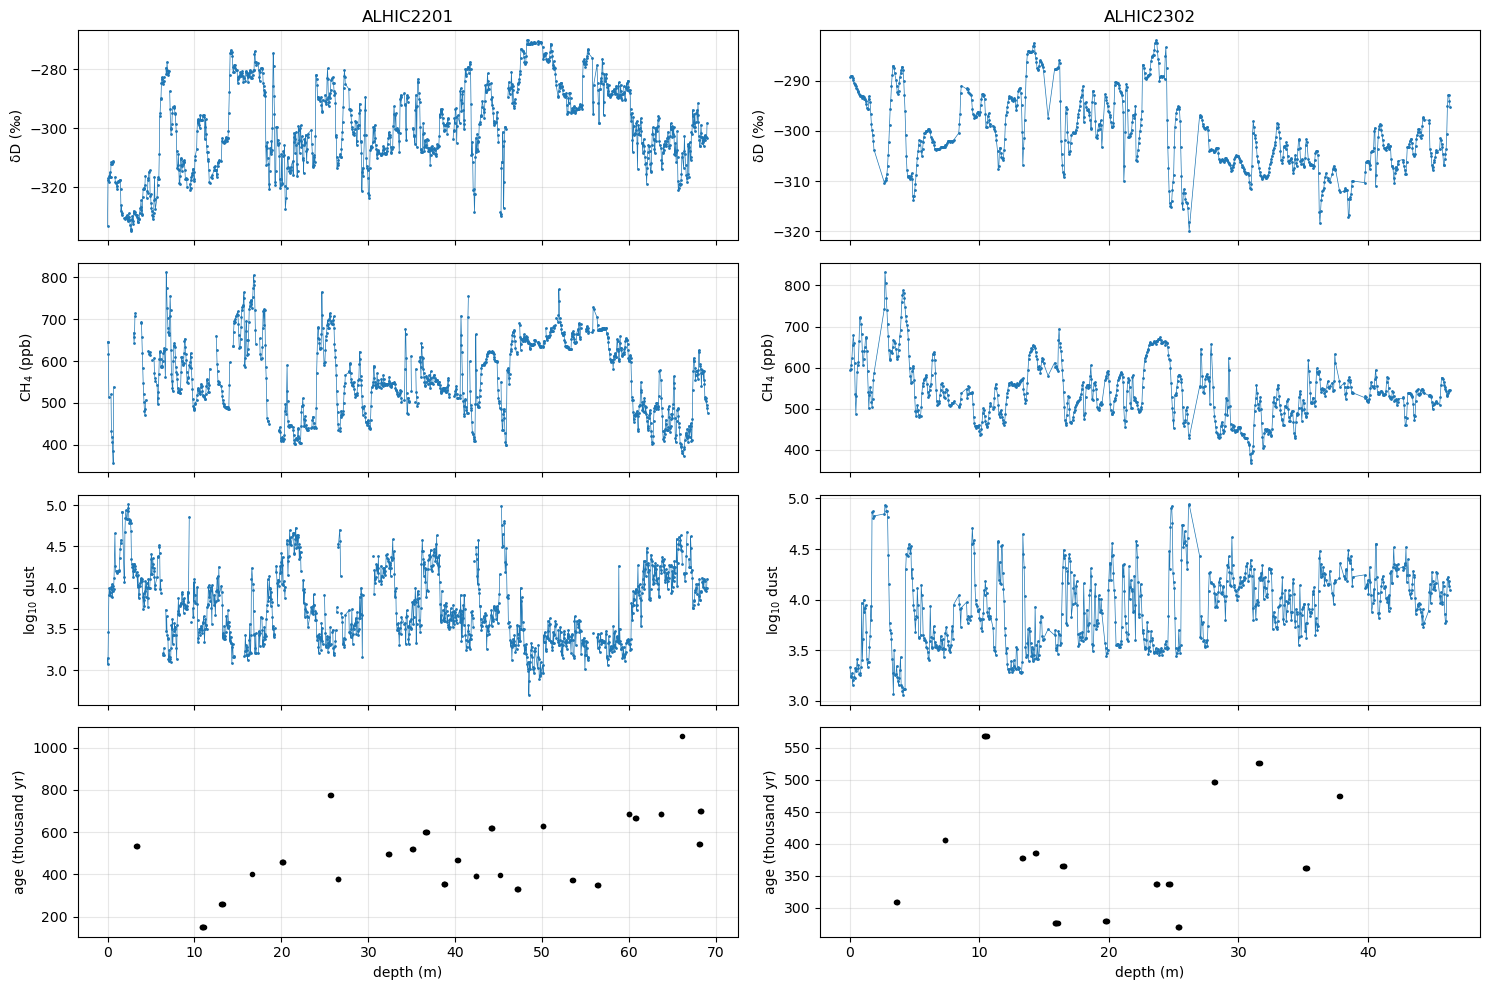

In [3]:
fig, ax = plt.subplots(4, 2, figsize=(15, 10), sharex='col')
rows = [('dD', 'δD (‰)'), ('CH4', 'CH$_4$ (ppb)'), ('logdust', 'log$_{10}$ dust'), ('age', 'age (thousand yr)')]
for j, (name, df) in enumerate(cores.items()):
    for i, (var, label) in enumerate(rows):
        if var == 'age':
            ax[i, j].plot(df.depth, df.age, 'ko', ms=3)
        else:
            ax[i, j].plot(df.depth, df[var], '.-', ms=2, lw=0.5)
        ax[i, j].set_ylabel(label)
        ax[i, j].grid(alpha=0.3)
    ax[0, j].set_title(name)
    ax[-1, j].set_xlabel('depth (m)')
plt.tight_layout(); plt.show()

## 4. What would Tierney & Ibarra's blurring actually do to this ice?

Before measuring anything, let's *see* the model. Their mixing step is a **Gaussian blur along depth**: each point is replaced by a weighted average of its neighbours, with nearby ice counting most and ice further away counting less, following a bell curve. σ is the width of that bell curve.

- σ = 5 cm → each point is averaged with roughly the ice within ±10 cm
- σ = 30 cm → roughly within ±60 cm
- σ = 75 cm → roughly within ±1.5 m

Two helper functions:

- `continuous_pieces()` splits a record wherever there's a gap in the measurements, so we never blur or interpolate across missing ice.
- `blur()` applies the Gaussian blur. It's the same operation as Tierney & Ibarra's equations 5–6.

In [4]:
def continuous_pieces(df, var, max_gap=0.15, min_points=8):
    # Split one variable into unbroken stretches, each on an exact 5 cm grid.
    d = df[['depth', var]].dropna()
    z_all, y_all = d.depth.values, d[var].values
    gap_positions = np.where(np.diff(z_all) > max_gap + 1e-9)[0] + 1
    pieces = []
    for idx in np.split(np.arange(len(z_all)), gap_positions):
        if len(idx) < min_points:
            continue
        z, y = z_all[idx], y_all[idx]
        z_grid = np.round(np.arange(z[0], z[-1] + STEP / 2, STEP), 3)
        pieces.append((z_grid, np.interp(z_grid, z, y)))   # fills any single missing sample
    return pieces

def blur(z, y, sigma):
    # Gaussian blur along depth with width sigma (metres), Tierney & Ibarra eq. 5-6.
    if sigma <= 0:
        return y.copy()
    dz = np.median(np.diff(z))
    half = int(np.ceil(4 * sigma / dz))
    bell = np.exp(-0.5 * (np.arange(-half, half + 1) * dz / sigma) ** 2)
    # dividing by the blurred "ones" keeps the ends of a piece from sagging toward zero
    return fftconvolve(y, bell, 'same') / fftconvolve(np.ones_like(y), bell, 'same')

Now take the longest unbroken stretch of δD in ALHIC2302 and blur it by 5, 30 and 75 cm.

Showing ALHIC2302 δD from 27.00 to 37.05 m


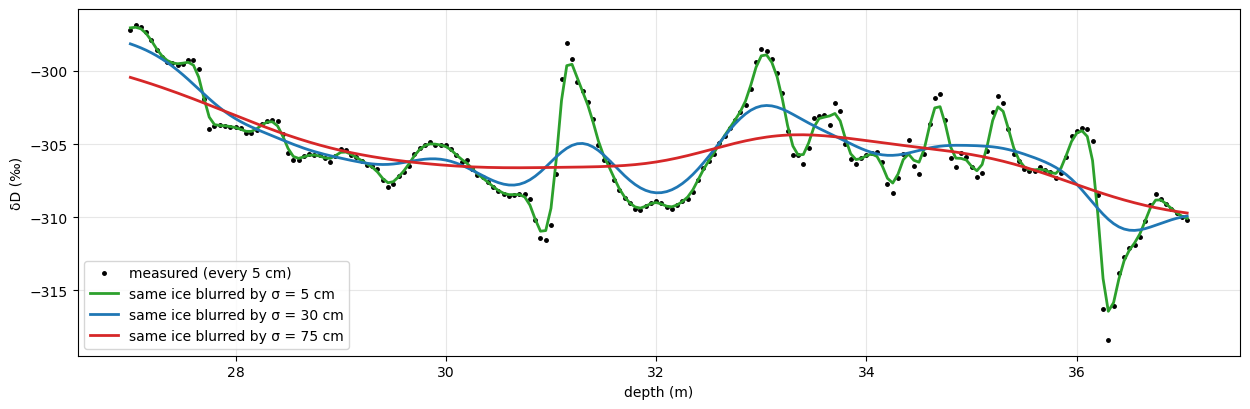

In [5]:
z, y = max(continuous_pieces(cores['ALHIC2302'], 'dD'), key=lambda p: len(p[0]))
print(f'Showing ALHIC2302 δD from {z[0]:.2f} to {z[-1]:.2f} m')

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(z, y, 'k.', ms=5, label='measured (every 5 cm)')
for sigma, color in [(0.05, 'C2'), (0.30, 'C0'), (0.75, 'C3')]:
    ax.plot(z, blur(z, y, sigma), color=color, lw=2, label=f'same ice blurred by σ = {sigma*100:.0f} cm')
ax.set_xlabel('depth (m)'); ax.set_ylabel('δD (‰)'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

**What this shows.** The black dots are the real ice. The green line (5 cm blur) barely changes it. The blue line is what **30 cm** of mixing would do: every sharp jump becomes a gentle slope spread over most of a metre, and the small wiggles disappear. The red line (**75 cm**, the value for CO₂) leaves only the broadest ups and downs.

This gives us a way to test the model:

- If the ice really had been blurred by 30 cm, the **measured** record would look like the blue line, with no sharp jumps anywhere.
- It clearly doesn't: the measured record has jumps that happen within one or two samples.

That's a picture, not a measurement. The rest of the notebook turns it into numbers.

## 5. A ruler for blur: fitting an S-curve to each contact

Zoom in on one contact. Before any mixing it's a clean **step**: ice at one value, then ice at another. Blur a step with a Gaussian and you get a smooth **S-shaped curve**. The width of that S is exactly σ, the blur amount. (Mathematically the S-curve is the *error function*, `erf`. You don't need the details, just that it's the exact shape Tierney & Ibarra's blur produces from a step.)

So, for every contact:

1. Fit an S-curve to the data around it.
2. Read off its width σ.

A handy way to picture σ: the S goes from 10% to 90% of the way across over a distance of about **2.5 × σ**.

| σ | depth needed to cross most of a contact |
|---|---|
| 4 cm | ~10 cm (two samples) |
| 30 cm | ~77 cm |
| 75 cm | ~1.9 m |

The fitted curve has five knobs:

- the level before the step
- the size of the step
- where the step is
- its width σ
- a gentle background slope, so that slow drifts either side of a contact aren't mistaken for blur

**One caveat about what σ measures.** The CFA instrument blurs things slightly too: meltwater mixes a bit as it flows through the tubing, and each value is an average over 5 cm. So the width we measure is **blur in the ice + blur from the instrument**. That means our σ is an *upper limit* on mixing in the ice. The real in-ice number can only be smaller.

In [6]:
def s_curve(params, z):
    # A blurred step: level a, step size b, position z0, width s, background slope c.
    a, b, z0, s, c = params
    return a + c * (z - z0) + 0.5 * b * (1 + erf((z - z0) / (np.sqrt(2) * s)))

def fit_s_curve(z, y, z0_guess, fixed_width=None):
    # Fit the S-curve. Returns (best parameters, sum of squared misfits).
    # If fixed_width is given, the width is held at that value and only the other
    # four knobs are adjusted - used below to ask "how well can a 30 cm curve fit?".
    level_before = np.mean(y[z < z0_guess][-4:])
    step_size = np.mean(y[z > z0_guess][:4]) - level_before
    if fixed_width is None:
        start = [level_before, step_size, z0_guess, 0.05, 0.0]
        low   = [-np.inf, -np.inf, z0_guess - 0.15, 0.003, -np.inf]
        high  = [ np.inf,  np.inf, z0_guess + 0.15, 3.0,    np.inf]
        r = least_squares(lambda p: s_curve(p, z) - y, start, bounds=(low, high))
        return r.x, np.sum(r.fun ** 2)
    misfit = lambda q: s_curve([q[0], q[1], q[2], fixed_width, q[3]], z) - y
    r = least_squares(misfit, [level_before, step_size, z0_guess, 0.0],
                      bounds=([-np.inf, -np.inf, z0_guess - 0.3, -np.inf],
                              [ np.inf,  np.inf, z0_guess + 0.3,  np.inf]))
    return np.r_[r.x[:3], fixed_width, r.x[3]], np.sum(r.fun ** 2)

## 6. Does the ruler work? Test it on fake data where we know the answer

Before trusting the ruler on real ice, test it on data where the answer is known:

1. Make a perfect step.
2. Blur it by a known σ.
3. Average it into 5 cm chunks like the CFA does.
4. Add random noise (about 1/20 of the step size).
5. Fit the S-curve and see whether we get the original σ back.

Repeat 100 times per σ to see the typical answer and the spread.

In [7]:
rng = np.random.default_rng(0)
z_fine = np.arange(-3, 3, 0.001)                       # 1 mm grid for the "true" ice
true_step = np.where(z_fine > 0.013, 20.0, 0.0)        # a step of 20 units
z_samples = np.round(np.arange(-0.6, 0.6, STEP), 3)    # CFA-style 5 cm samples, ±60 cm window

results = []
for true_sigma in [0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    blurred = blur(z_fine, true_step, true_sigma)
    sampled = np.array([blurred[(z_fine >= q - STEP/2) & (z_fine < q + STEP/2)].mean() for q in z_samples])
    fitted = [fit_s_curve(z_samples, sampled + rng.normal(0, 1, len(z_samples)), 0.0)[0][3]
              for _ in range(100)]
    results.append({'true σ (cm)': true_sigma * 100,
                    'typical fitted σ (cm)': np.median(fitted) * 100,
                    'low end (cm)': np.percentile(fitted, 5) * 100,
                    'high end (cm)': np.percentile(fitted, 95) * 100})
pd.DataFrame(results).round(1)

,true σ (cm),typical fitted σ (cm),low end (cm),high end (cm)
0,0.0,1.0,0.3,2.5
1,2.0,2.4,0.3,3.2
2,5.0,5.1,4.0,6.9
3,10.0,10.3,7.5,12.5
4,20.0,20.4,12.3,70.1
5,30.0,26.6,4.7,190.6
6,50.0,20.0,0.3,265.4


**How to read this.**

- **From about 2 to 20 cm, the ruler gets the right answer.** Blur we put in, we get back.
- **Below ~1–2 cm it bottoms out**, because 5 cm samples can't show anything finer. A perfectly sharp step still reads as ~1 cm.
- **Above ~30 cm the answer becomes unreliable in a ±60 cm window.** A very wide S looks almost like a straight line, which is hard to tell apart from a slope.

That last point sounds like a problem, but it isn't for this question. We aren't trying to measure a 30 cm blur precisely. We're asking whether the contacts are **much sharper** than 30 cm. The ruler answers that well: if it reports 4 cm, the contact is genuinely sharp.

## 7. Find the contacts in the real ice

We need an automatic, unbiased way to find contacts rather than picking the ones we like. The method is deliberately simple:

- At every depth, compare the **average of the next 20 cm** with the **average of the previous 20 cm**.
- Where that difference is unusually large, much bigger than the normal sample-to-sample noise, there's probably a contact.
- Keep the biggest ones, at least 40 cm apart.

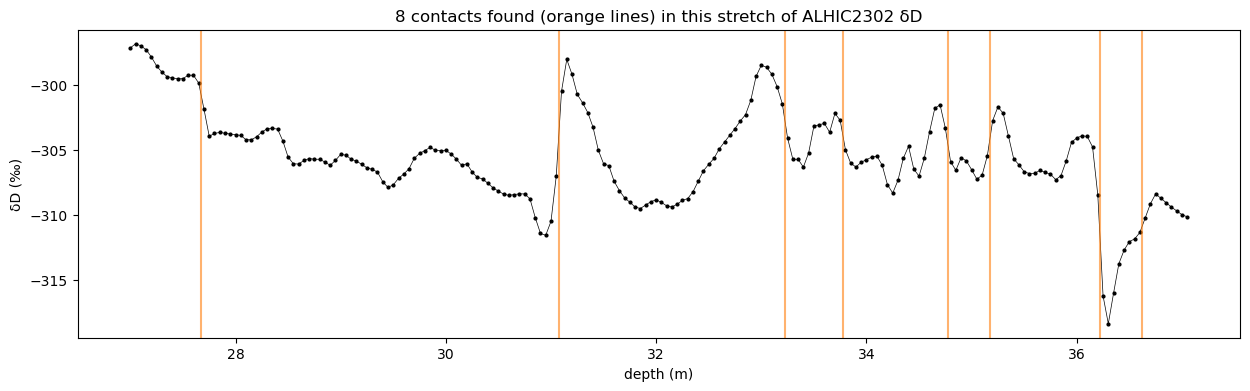

In [8]:
def find_contacts(z, y, k=4, min_separation=0.4, how_unusual=6):
    # Return depths where the next-20-cm average differs sharply from the previous-20-cm average.
    difference = np.full(len(y), np.nan)
    for i in range(k, len(y) - k + 1):
        difference[i] = np.mean(y[i:i + k]) - np.mean(y[i - k:i])
    # typical sample-to-sample noise, estimated in a way that ignores the big jumps themselves
    d = np.diff(y)
    noise = 1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2)
    peaks, _ = find_peaks(np.nan_to_num(np.abs(difference)),
                          height=how_unusual * noise, distance=int(min_separation / STEP))
    return [z[i] - STEP / 2 for i in peaks]           # contact lies between two samples

# Show what the finder picks out on the same stretch as before
z, y = max(continuous_pieces(cores['ALHIC2302'], 'dD'), key=lambda p: len(p[0]))
found = find_contacts(z, y)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(z, y, 'k.-', ms=4, lw=0.5)
for zc in found:
    ax.axvline(zc, color='C1', alpha=0.6)
ax.set_title(f'{len(found)} contacts found (orange lines) in this stretch of ALHIC2302 δD')
ax.set_xlabel('depth (m)'); ax.set_ylabel('δD (‰)')
plt.show()

## 8. Measure every contact, and ask how badly a 30 cm or 75 cm curve fits

For each contact we:

1. Take the data within ±60 cm, cut short if another contact is closer, so two steps never get fit as one.
2. Fit the S-curve and record its width σ.
3. **Ask how well each possible blur amount could fit.** Hold the width fixed at 1 cm, 2 cm, … up to 100 cm, re-fit the other knobs each time, and see how much worse the fit gets. From this we get:
   - a **95% range** of widths the data can accept (`low95`–`high95`)
   - a score for Tierney & Ibarra's specific values (`penalty_30cm`, `penalty_75cm`)

   A penalty above **3.84** means that width is ruled out at 95% confidence for that contact. Above 6.6 means 99% confidence.

Then some quality control, to throw out fits that aren't really describing a step:

- the fitted "step" is bigger than the whole record's range, meaning the curve got stretched into a long ramp
- the 95% range runs off the end of what we tested, meaning the width couldn't be pinned down
- the step is small compared with the noise

This cell takes about 30 seconds.

In [9]:
WIDTHS_TO_TRY = np.r_[0.003, np.arange(0.01, 1.01, 0.01)]   # 0.3 cm, then 1 cm steps to 1 m

def measure_contacts(core, var, window=0.6, pieces_fn=continuous_pieces):
    rows = []
    for z_piece, y_piece in pieces_fn(cores[core], var):
        contacts = find_contacts(z_piece, y_piece)
        for j, z0 in enumerate(contacts):
            # window around this contact, stopping halfway to its neighbours
            lo = max(z0 - window, (contacts[j-1] + z0) / 2 if j > 0 else -np.inf)
            hi = min(z0 + window, (contacts[j+1] + z0) / 2 if j < len(contacts) - 1 else np.inf)
            keep = (z_piece >= lo) & (z_piece <= hi)
            z, y = z_piece[keep], y_piece[keep]
            if (z < z0).sum() < 3 or (z > z0).sum() < 3:
                continue
            best, best_misfit = fit_s_curve(z, y, z0)
            noise_var = best_misfit / (len(z) - 5)
            # how much worse does the fit get if we force each width?
            forced = np.array([fit_s_curve(z, y, z0, fixed_width=w)[1] for w in WIDTHS_TO_TRY])
            penalty = (forced - forced.min()) / noise_var
            acceptable = WIDTHS_TO_TRY[penalty < chi2.ppf(0.95, 1)]      # 3.84
            rows.append(dict(core=core, var=var, depth=best[2], step_size=best[1], sigma=best[3],
                             slope=best[4], low95=acceptable.min(), high95=acceptable.max(),
                             noise=np.sqrt(noise_var),
                             penalty_30cm=np.interp(0.30, WIDTHS_TO_TRY, penalty),
                             penalty_75cm=np.interp(0.75, WIDTHS_TO_TRY, penalty)))
    return pd.DataFrame(rows)

def quality_ok(table):
    full_range = table.apply(lambda r: np.ptp(cores[r.core][r['var']].dropna()), axis=1)
    return ((table.step_size.abs() < full_range) &
            (table.high95 < 1.0) &
            (table.step_size.abs() / table.noise > 4))

VARIABLES = ['dD', 'CH4', 'logdust']
everything = pd.concat([measure_contacts(c, v) for c in cores for v in VARIABLES], ignore_index=True)
everything['passes_qc'] = quality_ok(everything)
contacts = everything[everything.passes_qc].copy()

print('How many contacts were found, and how many passed quality control:')
print(everything.groupby(['core', 'var']).passes_qc.agg(found='size', kept='sum'))
contacts.head(10).round(3)

How many contacts were found, and how many passed quality control:
                   found  kept
core      var                 
ALHIC2201 CH4         36    30
          dD          37    26
          logdust     10     7
ALHIC2302 CH4         31    24
          dD          36    28
          logdust     21    14


,core,var,depth,step_size,sigma,slope,low95,high95,noise,penalty_30cm,penalty_75cm,passes_qc
0,ALHIC2201,dD,0.025,14.109,0.004,12.914,0.010,0.06,1.342,55.754,62.223,True
1,ALHIC2201,dD,1.511,-11.198,0.021,3.457,0.003,0.05,1.018,31.969,41.563,True
3,ALHIC2201,dD,4.921,-27.844,0.097,39.403,0.060,0.22,1.836,5.055,6.700,True
5,ALHIC2201,dD,5.970,22.765,0.038,21.176,0.010,0.15,2.289,11.340,15.939,True
6,ALHIC2201,dD,7.143,-26.463,0.081,16.721,0.040,0.24,2.535,4.609,6.209,True
8,ALHIC2201,dD,10.205,18.718,0.132,-0.889,0.080,0.22,1.834,6.579,11.126,True
10,ALHIC2201,dD,12.654,5.593,0.038,-6.618,0.010,0.11,0.898,7.904,9.021,True
11,ALHIC2201,dD,14.002,31.015,0.081,1.832,0.070,0.09,0.687,101.438,225.935,True
13,ALHIC2201,dD,16.798,9.628,0.085,-8.148,0.003,0.20,1.523,5.794,7.340,True
14,ALHIC2201,dD,18.195,-16.078,0.003,-22.225,0.003,0.03,2.816,20.832,21.619,True


## 9. The main result

First the widths themselves (in cm), then the key question: **for what fraction of contacts is each blur amount ruled out?**

In [10]:
widths = contacts.groupby('var').sigma       # widths in metres
print('Measured contact widths (cm):')
print(pd.DataFrame({'contacts': widths.size(),
                    'typical (median)': widths.median() * 100,
                    'middle half from': widths.quantile(0.25) * 100,
                    'middle half to': widths.quantile(0.75) * 100,
                    'widest': widths.max() * 100}).round(1))

ruled_out = pd.DataFrame({f'σ = {w*100:.0f} cm ruled out': contacts.groupby('var').high95.apply(lambda h: (h < w).mean())
                          for w in [0.10, 0.15, 0.30, 0.75]})
print('\nFraction of contacts that rule out each blur amount (95% confidence):')
print(ruled_out.round(2))

Measured contact widths (cm):
         contacts  typical (median)  middle half from  middle half to  widest
var                                                                          
CH4            54               5.2               3.6             9.5    19.0
dD             54               4.3               2.3             8.6    14.5
logdust        21               3.0               1.4             5.4    19.0

Fraction of contacts that rule out each blur amount (95% confidence):
         σ = 10 cm ruled out  σ = 15 cm ruled out  σ = 30 cm ruled out  σ = 75 cm ruled out
var                                                                                        
CH4                     0.57                 0.69                 0.96                  1.0
dD                      0.57                 0.70                 0.94                  1.0
logdust                 0.67                 0.76                 0.90                  1.0


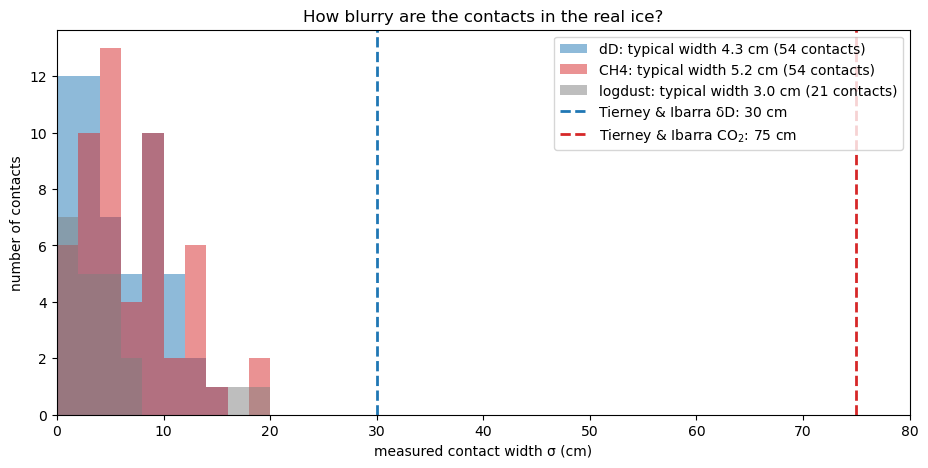

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.arange(0, 0.42, 0.02) * 100
for var, color in zip(VARIABLES, ['C0', 'C3', 'C7']):
    sub = contacts[contacts['var'] == var]
    ax.hist(sub.sigma * 100, bins=bins, alpha=0.5, color=color,
            label=f'{var}: typical width {sub.sigma.median()*100:.1f} cm ({len(sub)} contacts)')
ax.axvline(30, color='C0', ls='--', lw=2, label='Tierney & Ibarra δD: 30 cm')
ax.axvline(75, color='C3', ls='--', lw=2, label='Tierney & Ibarra CO$_2$: 75 cm')
ax.set_xlim(0, 80)
ax.set_xlabel('measured contact width σ (cm)'); ax.set_ylabel('number of contacts')
ax.legend(); ax.set_title('How blurry are the contacts in the real ice?')
plt.show()

**What this shows.**

- **The typical contact is only about 4–5 cm wide** for both δD and CH₄. That's about the limit of what 5 cm sampling can see.
- **Nearly every contact (≳ 94%) is individually too sharp for 30 cm of blur.**
- **Every contact is too sharp for 75 cm.**
- **Dust (grey) is useful as a reference.** Dust particles are solid and can't move through ice, so a dust contact is only blurred by the instrument. Dust contacts measure about 3 cm, close to δD and CH₄. So most of the few centimetres we measure is probably instrument blur, not mixing in the ice.

Now let's look at a few individual contacts. For each one, the solid line is the best fit. The dashed and dotted lines are **the same step, blurred by 30 cm and 75 cm**: what Tierney & Ibarra's model says that contact should look like.

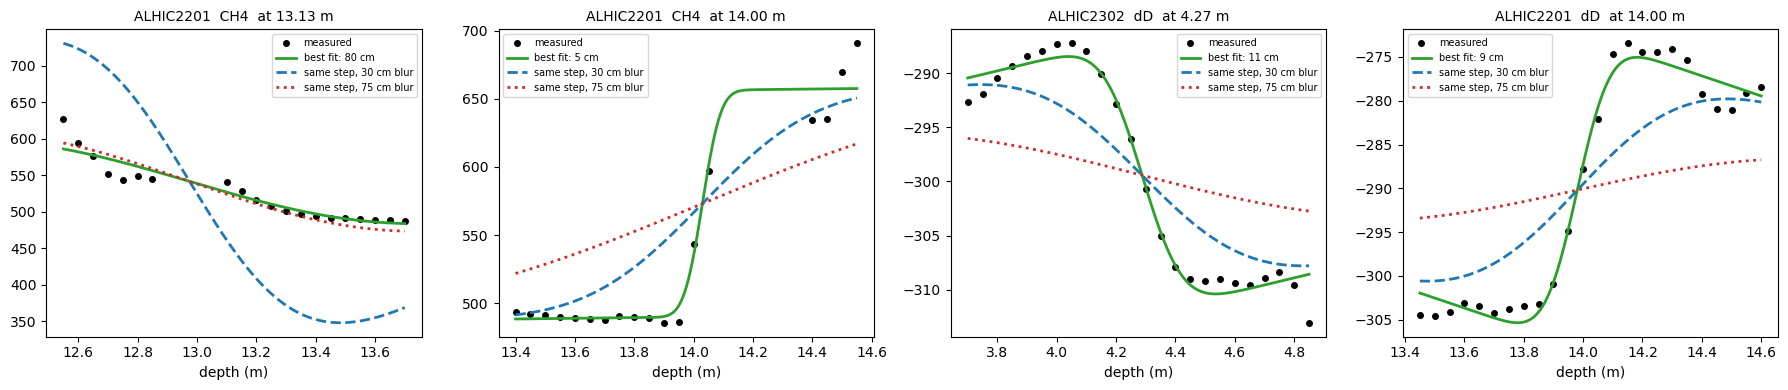

In [12]:
# pick the clearest contacts: big step compared with the noise, and not dominated by background slope
clear = (contacts[contacts['var'].isin(['dD', 'CH4']) &
                  (contacts.slope.abs() * 1.2 < 0.5 * contacts.step_size.abs())]
         .assign(clarity=lambda d: d.step_size.abs() / d.noise)
         .sort_values('clarity', ascending=False).groupby('var').head(2))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for a, (_, r) in zip(axes, clear.iterrows()):
    df = cores[r.core]
    near = (df.depth > r.depth - 0.6) & (df.depth < r.depth + 0.6) & df[r['var']].notna()
    z_w, y_w = df.depth[near].values, df[r['var']][near].values
    best, _ = fit_s_curve(z_w, y_w, r.depth)
    zz = np.linspace(z_w.min(), z_w.max(), 400)
    a.plot(z_w, y_w, 'ko', ms=4, label='measured')
    a.plot(zz, s_curve(best, zz), 'C2', lw=2, label=f'best fit: {best[3]*100:.0f} cm')
    a.plot(zz, s_curve(np.r_[best[:3], 0.30, best[4]], zz), 'C0--', lw=2, label='same step, 30 cm blur')
    a.plot(zz, s_curve(np.r_[best[:3], 0.75, best[4]], zz), 'C3:', lw=2, label='same step, 75 cm blur')
    a.set_title(f"{r.core}  {r['var']}  at {r.depth:.2f} m", fontsize=10)
    a.set_xlabel('depth (m)'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 10. Challenge #1: is the contact finder only noticing sharp contacts?

A fair objection: maybe the contact finder is simply better at spotting sharp jumps, and misses blurry ones. Then the sharp widths above could be an artefact of the method, not a property of the ice.

We can check this directly:

1. **Blur the real data ourselves** by a known amount (0, 5, 15, 30, 75 cm).
2. **Run the exact same pipeline** on the blurred data.
3. See whether it notices the blur.

If the method is fair, the widths it measures should grow roughly as √(original² + added²). The `expected` column shows that prediction.

This also answers another question directly: *if Tierney & Ibarra were right, what would we have measured?* The answer is the 30 cm row, not the 0 cm row.

⏱ This cell re-runs the whole analysis 10 times and takes about 3–4 minutes.

In [13]:
def blurred_pieces(amount):
    return lambda df, var: [(z, blur(z, y, amount)) for z, y in continuous_pieces(df, var)]

rows = []
for added in [0.0, 0.05, 0.15, 0.30, 0.75]:
    for var in ['dD', 'CH4']:
        t = pd.concat([measure_contacts(c, var, pieces_fn=blurred_pieces(added)) for c in cores])
        t = t[quality_ok(t)]
        original = contacts[contacts['var'] == var].sigma.median()
        rows.append({'blur added (cm)': added * 100, 'var': var, 'contacts found': len(t),
                     'measured width (cm)': t.sigma.median() * 100,
                     'expected (cm)': np.sqrt(original**2 + added**2) * 100})
pd.DataFrame(rows).round(1)

,blur added (cm),var,contacts found,measured width (cm),expected (cm)
0,0.0,dD,54,4.3,4.3
1,0.0,CH4,54,5.2,5.2
2,5.0,dD,75,7.4,6.6
3,5.0,CH4,69,7.2,7.2
4,15.0,dD,73,15.2,15.6
5,15.0,CH4,82,14.8,15.9
6,30.0,dD,53,33.5,30.3
7,30.0,CH4,43,35.3,30.4
8,75.0,dD,15,38.4,75.1
9,75.0,CH4,12,38.3,75.2


**What this shows.** When we add 15 or 30 cm of blur, the pipeline measures about 15 or 30 cm, as it should. (At 75 cm it under-reads, which is the window-size limit from section 6, and it also finds far fewer contacts.)

So the method *would* have seen Tierney-sized blur if it were there. The real ice matches the **0 cm** row.

## 11. Challenge #2: a second ruler that doesn't need contacts at all

Everything so far depends on finding contacts. Here's a completely separate way to measure blur, which uses the *whole* record.

**The idea.** Any wiggly record can be thought of as many wiggles of different sizes added together: long slow swings plus short quick jiggles, a bit like bass and treble in music. Blurring removes the **short wiggles first**. It works like a treble knob, and the more blur, the more treble is cut.

A **power spectrum** shows how much wiggle there is at each size:

- left side = long wiggles (few per metre)
- right side = short wiggles (many per metre)

A Gaussian blur of σ cuts the short wiggles in a very specific way, so we can fit the spectrum and read σ off it. This is also how Shaw et al. (2024) estimated the 31 cm mixing at the bottom of the EPICA Dome C core, the study Tierney & Ibarra cite.

In each plot:

- **Black dots:** the real spectrum.
- **Red line:** the best fit and its σ.
- **Blue dashed line:** the same fit with Tierney & Ibarra's σ. Short wiggles would be crushed down to the noise floor almost immediately.

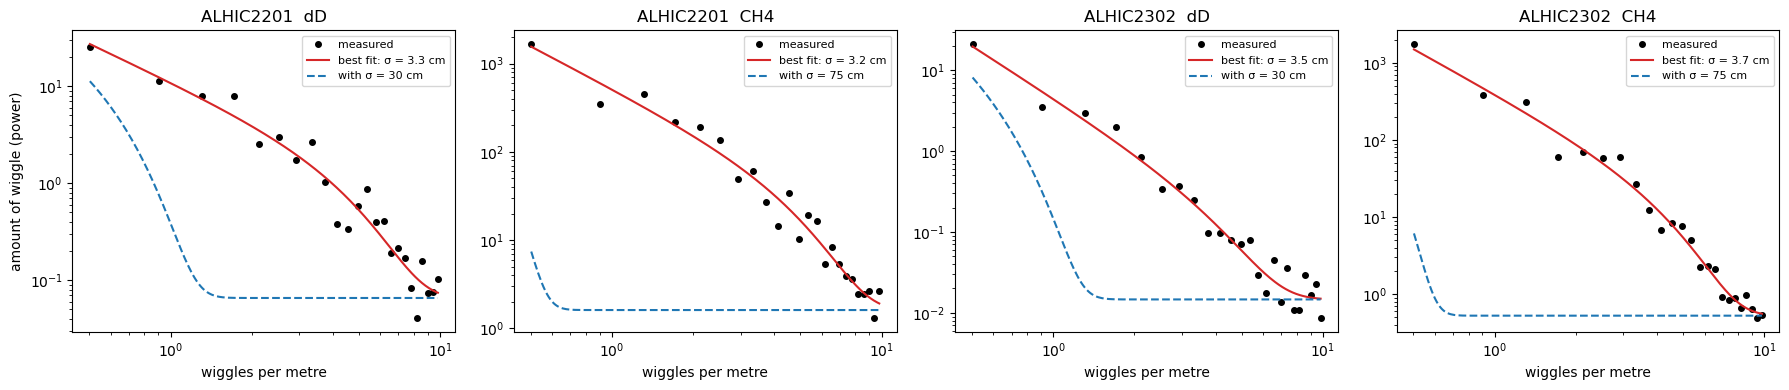

,core,var,σ from spectrum (cm),± (cm)
0,ALHIC2201,dD,3.3,0.7
1,ALHIC2201,CH4,3.2,0.6
2,ALHIC2302,dD,3.5,0.8
3,ALHIC2302,CH4,3.7,0.4


In [14]:
def average_spectrum(core, var, min_length=3.0, bin_edges=np.linspace(0.3, 10, 25)):
    spectra = []
    for z, y in continuous_pieces(cores[core], var):
        if z[-1] - z[0] < min_length:
            continue
        y = y - np.polyval(np.polyfit(z, y, 1), z)      # remove the overall tilt
        taper = np.hanning(len(y))                       # soften the ends of each piece
        F = np.fft.rfft(y * taper)
        f = np.fft.rfftfreq(len(y), STEP)                # wiggles per metre
        spectra.append((f[1:], np.abs(F[1:])**2 * STEP / np.sum(taper**2)))
    centres, power = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):   # average all pieces together
        vals = np.concatenate([p[(f >= lo) & (f < hi)] for f, p in spectra])
        if len(vals):
            centres.append((lo + hi) / 2); power.append(vals.mean())
    return np.array(centres), np.array(power)

def spectrum_model(f, logA, slope, sigma, log_noise):
    # natural wiggles (a power law) x blur filter + flat measurement noise
    return np.log(10**logA * f**-slope * np.exp(-(2*np.pi*f*sigma)**2) + 10**log_noise)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
summary = []
for a, (core, var) in zip(axes, [(c, v) for c in cores for v in ['dD', 'CH4']]):
    f, P = average_spectrum(core, var)
    p, cov = curve_fit(spectrum_model, f, np.log(P), p0=[0, 2, 0.03, -3],
                       bounds=([-10, 0, 0, -10], [10, 4, 1, 5]))
    summary.append({'core': core, 'var': var, 'σ from spectrum (cm)': p[2] * 100,
                    '± (cm)': np.sqrt(cov[2, 2]) * 100})
    ff = np.logspace(np.log10(f[0]), np.log10(f[-1]), 200)
    a.loglog(f, P, 'ko', ms=4, label='measured')
    a.loglog(ff, np.exp(spectrum_model(ff, *p)), 'C3', label=f'best fit: σ = {p[2]*100:.1f} cm')
    a.loglog(ff, np.exp(spectrum_model(ff, p[0], p[1], TIERNEY_SIGMA[var], p[3])), 'C0--',
             label=f'with σ = {TIERNEY_SIGMA[var]*100:.0f} cm')
    a.set_title(f'{core}  {var}'); a.set_xlabel('wiggles per metre'); a.legend(fontsize=8)
axes[0].set_ylabel('amount of wiggle (power)')
plt.tight_layout(); plt.show()
pd.DataFrame(summary).round(1)

**What this shows.** The real records keep plenty of short-scale wiggle, all the way down to wiggles only ~10–20 cm long. The fitted blur is **~3–4 cm** in both cores, for both δD and CH₄. That agrees with the contact method, even though this method never looks for contacts.

If the ice had been blurred by 30 cm (δD) or 75 cm (CH₄), the black dots would follow the blue dashed line and fall to the noise floor at about 1 wiggle per metre. They don't.

## 12. Do gases blur more than the ice itself?

Tierney & Ibarra's numbers say gases (CO₂, 75 cm) mix about **2.5 times more** than water isotopes (δD, 30 cm). That's physically plausible, since gases can move through ice more easily than the ice's own water molecules. We can check the *ratio* directly, because CH₄ and δD are measured on the same ice.

Where a δD contact and a CH₄ contact fall at the same depth (within 10 cm), compare their widths. Dust, which can't move at all, gives the instrument-only baseline.

In [15]:
print('Typical measured width (cm):')
print((contacts.groupby('var').sigma.median() * 100).round(1).to_string())

pairs = []
for c in cores:
    d_rows = contacts[(contacts.core == c) & (contacts['var'] == 'dD')]
    m_rows = contacts[(contacts.core == c) & (contacts['var'] == 'CH4')]
    for _, r in d_rows.iterrows():
        dist = (m_rows.depth - r.depth).abs()
        if len(dist) and dist.min() < 0.10:
            m = m_rows.loc[dist.idxmin()]
            pairs.append({'core': c, 'depth (m)': r.depth,
                          'δD width (cm)': r.sigma * 100, 'CH4 width (cm)': m.sigma * 100})
pairs = pd.DataFrame(pairs)
ratio = np.median(pairs['CH4 width (cm)'] / pairs['δD width (cm)'])
print(f'\nAt {len(pairs)} shared contacts, CH4 is typically {ratio:.1f}x as wide as δD '
      f'(Tierney & Ibarra imply about 2.5x).')
pairs.round(1)

Typical measured width (cm):
var
CH4        5.2
dD         4.3
logdust    3.0

At 7 shared contacts, CH4 is typically 1.2x as wide as δD (Tierney & Ibarra imply about 2.5x).


,core,depth (m),δD width (cm),CH4 width (cm)
0,ALHIC2201,6.0,3.8,4.7
1,ALHIC2201,14.0,8.1,0.3
2,ALHIC2201,42.3,0.6,3.0
3,ALHIC2201,53.3,0.7,3.2
4,ALHIC2302,3.8,11.8,15.2
5,ALHIC2302,12.0,11.3,11.0
6,ALHIC2302,43.1,11.9,9.3


**What this shows.** Measured contact widths are CH₄ ≈ 5 cm, δD ≈ 4 cm and dust ≈ 3 cm. At the few contacts where δD and CH₄ line up, CH₄ is only ~1.2× as wide, not 2.5×.

Caveats:

- There are only 7 shared contacts, so treat this as a first look.
- CH₄ goes through a separate gas-extraction line in the CFA system, which adds some blur of its own.
- CH₄ isn't CO₂. The two gases move through ice at different rates.

## 13. What this does and doesn't show

**In plain terms:** the Allan Hills CFA records contain dozens of contacts, where ice of one age meets ice of another, and they are **sharp**, typically ~4–5 cm wide. That's close to the resolution of the measurement itself. The Gaussian blur Tierney & Ibarra use (30 cm for water isotopes, 75 cm for CO₂) would have smeared every one of these contacts over most of a metre or more. Three separate checks agree:

1. Fitting individual contacts: section 9.
2. Showing the method *would* detect that much blur if it were there: section 10.
3. Measuring blur from the whole record without contacts: section 11.

**What it doesn't (yet) show:**

- **These are different, shallower cores.** Tierney & Ibarra's numbers are for the deep (>140 m), 1–3 million-year-old section of ALHIC1901. These cores are <70 m deep, with ice ~150–1050 thousand years old. If mixing works like diffusion, blur grows with the *square root of time*, so older ice should be blurrier. Scaling 30 cm at ~2 million years back to ~500 thousand years gives ~15 cm. About 70% of contacts still rule out 15 cm, but this age question is the most important thing to test next.
- **Our widths are upper limits.** They include instrument blur, which makes this test *generous* to Tierney & Ibarra, not harsh.
- **The 95% ranges for individual contacts are a bit too narrow.** Neighbouring measurements aren't fully independent, and the fit treats them as if they were. Sections 10 and 11 don't rely on those ranges, and they agree.
- **It doesn't say the ice is unaltered.** It says the specific *smooth Gaussian blur over tens of centimetres* doesn't match this ice. Other kinds of alteration, such as chemistry, respiration, or mixing concentrated in particular layers, aren't tested here.

**Possible next steps:**

1. Give each contact the age of the nearest dated sample and check whether older contacts are blurrier, and by the √time amount diffusion predicts.
2. Run Tierney & Ibarra's own recipe on these cores: choose σ so the simulated record's variability matches the real one, using the EPICA Dome C record as the "truth". Would their method report ~30 cm here even though the contacts are ~4 cm? If so, that points to a problem with the recipe itself.
3. Use the dust contacts, or a direct measurement of the CFA system's own blur, to subtract instrument blur and estimate in-ice mixing on its own.

In [16]:
# For every contact: how well does an S-curve of each candidate width fit?
# Neighbouring 5 cm samples aren't independent (the CFA smooths a little), so
# each contact is counted as fewer "effective" data points. Without this
# correction the evidence would be overstated.

def contact_likelihoods(core, var, window=0.6):
    rows = []
    for z_piece, y_piece in continuous_pieces(cores[core], var):
        found = find_contacts(z_piece, y_piece)
        for j, z0 in enumerate(found):
            # window around the contact, stopping halfway to its neighbours
            lo = max(z0 - window, (found[j-1] + z0) / 2 if j > 0 else -np.inf)
            hi = min(z0 + window, (found[j+1] + z0) / 2 if j < len(found) - 1 else np.inf)
            keep = (z_piece >= lo) & (z_piece <= hi)
            z, y = z_piece[keep], y_piece[keep]
            if (z < z0).sum() < 3 or (z > z0).sum() < 3:
                continue
            best, _ = fit_s_curve(z, y, z0)
            # how strongly does each leftover misfit predict the next one? (0 = not at all)
            leftovers = s_curve(best, z) - y
            rho = np.clip(np.corrcoef(leftovers[:-1], leftovers[1:])[0, 1], 0, 0.95)
            n_effective = max(3.0, len(z) * (1 - rho) / (1 + rho))
            # fit quality with the width forced to each candidate value
            misfit = np.array([fit_s_curve(z, y, z0, fixed_width=w)[1] for w in WIDTHS_TO_TRY])
            log_lik = -0.5 * n_effective * np.log(misfit)        # standard Gaussian-noise likelihood
            rows.append(dict(core=core, var=var, depth=best[2], sigma=best[3],
                             n_points=len(z), n_effective=n_effective,
                             log_lik=log_lik - log_lik.max()))   # 0 at the best width
    return pd.DataFrame(rows)

PROXIES = ['dD', 'd18O', 'CH4', 'logdust']   # logdust = reference: particles can't move through ice
lik = pd.concat([contact_likelihoods(c, v) for c in cores for v in PROXIES], ignore_index=True)
print(lik.groupby('var').agg(contacts=('sigma', 'size'),
                             typical_points=('n_points', 'median'),
                             typical_effective_points=('n_effective', 'median')).round(1))


         contacts  typical_points  typical_effective_points
var                                                        
CH4            67            18.0                       9.4
d18O           58            19.0                      10.8
dD             73            17.0                       9.3
logdust        31            18.0                      11.0


In [17]:
from scipy.special import logsumexp   # adds up very small probabilities without rounding to zero

# Tierney & Ibarra's sigma per proxy, with the ±10 cm they say is also compatible (their Fig. S1).
# d18O isn't in their paper; we assume it behaves like dD. CH4 stands in for CO2.
TIERNEY_RANGE = {'dD': (0.20, 0.40), 'd18O': (0.20, 0.40), 'CH4': (0.65, 0.85)}

# "Blur is a minimum" (deliberately generous to Tierney & Ibarra): a contact can be WIDER
# than the blur for innocent reasons (instrument smoothing, gradual climate change) but never
# SHARPER. So a contact's score at sigma = the best score it can reach with any width >= sigma.
# Wide contacts never count against Tierney; only contacts too sharp for their sigma do.
lik['floor_log_lik'] = lik.log_lik.apply(lambda ll: np.maximum.accumulate(ll[::-1])[::-1])

def younger_neighbouring_age(core, depth):
    # Age (ka) of the younger of the two nearest dated samples. Younger = less time to
    # diffuse = smallest predicted blur, i.e. the generous choice.
    dated = cores[core].dropna(subset=['age'])
    above, below = dated[dated.depth <= depth], dated[dated.depth > depth]
    ages = ([above.iloc[-1].age] if len(above) else []) + ([below.iloc[0].age] if len(below) else [])
    return min(ages)

lik['age_ka'] = [younger_neighbouring_age(r.core, r.depth) for r in lik.itertuples()]

def combined_evidence(contacts_subset, reference_age_ka=None):
    # Total log-likelihood for each candidate shared sigma, summed over contacts
    # (summing logs = multiplying probabilities). If reference_age_ka is given, the
    # model is "diffusion-like": each contact is tested against
    # sigma * sqrt(its age / reference age), i.e. younger ice is blurred less.
    total = np.zeros_like(WIDTHS_TO_TRY)
    for r in contacts_subset.itertuples():
        scale = 1.0 if reference_age_ka is None else np.sqrt(r.age_ka / reference_age_ka)
        total += np.interp(WIDTHS_TO_TRY * scale, WIDTHS_TO_TRY, r.floor_log_lik)
    return total

def probability_tierney(total, tierney_range):
    # Bayes with 50/50 prior odds between:
    #   'Tierney is right'  = sigma uniform over their range
    #   'something else'    = sigma uniform over 0-1 m (includes their range, so not rigged)
    # Returns log10 of the odds and P(Tierney | data).
    in_range = (WIDTHS_TO_TRY >= tierney_range[0]) & (WIDTHS_TO_TRY <= tierney_range[1])
    avg_evidence = lambda mask: logsumexp(total[mask]) - np.log(mask.sum())   # log of the average likelihood
    log10_odds = (avg_evidence(in_range) - avg_evidence(np.ones_like(in_range))) / np.log(10)
    return log10_odds, 1 / (1 + 10 ** (-log10_odds))

def best_estimate(total):
    # Most likely shared blur and its 95% range (cm), under 'something else'.
    p = np.exp(total - total.max()); p /= p.sum(); c = np.cumsum(p)
    return [WIDTHS_TO_TRY[np.searchsorted(c, q)] * 100 for q in (0.5, 0.025, 0.975)]

rows = []
for var in PROXIES:
    sub = lik[lik['var'] == var]
    for label, ref_age in [('as published', None), ('age-scaled, 2 Ma', 2000), ('age-scaled, 3 Ma', 3000)]:
        total = combined_evidence(sub, ref_age)
        typical, low, high = best_estimate(total)
        row = {'proxy': var, 'Tierney σ': label, 'contacts': len(sub),
               'best shared blur (cm)': typical, '95% range (cm)': f'{low:.0f}–{high:.0f}'}
        if var in TIERNEY_RANGE:
            log10_odds, p = probability_tierney(total, TIERNEY_RANGE[var])
            row.update({'log10 odds': round(log10_odds, 1), 'P(Tierney | data)': f'{p:.2g}'})
        rows.append(row)
main_table = pd.DataFrame(rows)
main_table


,proxy,Tierney σ,contacts,best shared blur (cm),95% range (cm),log10 odds,P(Tierney | data)
0,dD,as published,73,1.0,0–2,-113.0,9.2e-114
1,dD,"age-scaled, 2 Ma",73,1.0,0–4,-40.6,2.8e-41
2,dD,"age-scaled, 3 Ma",73,2.0,0–5,-30.1,8.8e-31
3,d18O,as published,58,1.0,0–2,-90.2,7.1e-91
4,d18O,"age-scaled, 2 Ma",58,2.0,0–4,-38.1,8.3e-39
5,d18O,"age-scaled, 3 Ma",58,2.0,0–5,-28.0,8.9e-29
6,CH4,as published,67,1.0,0–2,-143.8,1.6e-144
7,CH4,"age-scaled, 2 Ma",67,2.0,0–6,-116.7,2.1e-117
8,CH4,"age-scaled, 3 Ma",67,3.0,0–7,-103.0,9.8e-104
9,logdust,as published,31,1.0,0–2,NaN,NaN


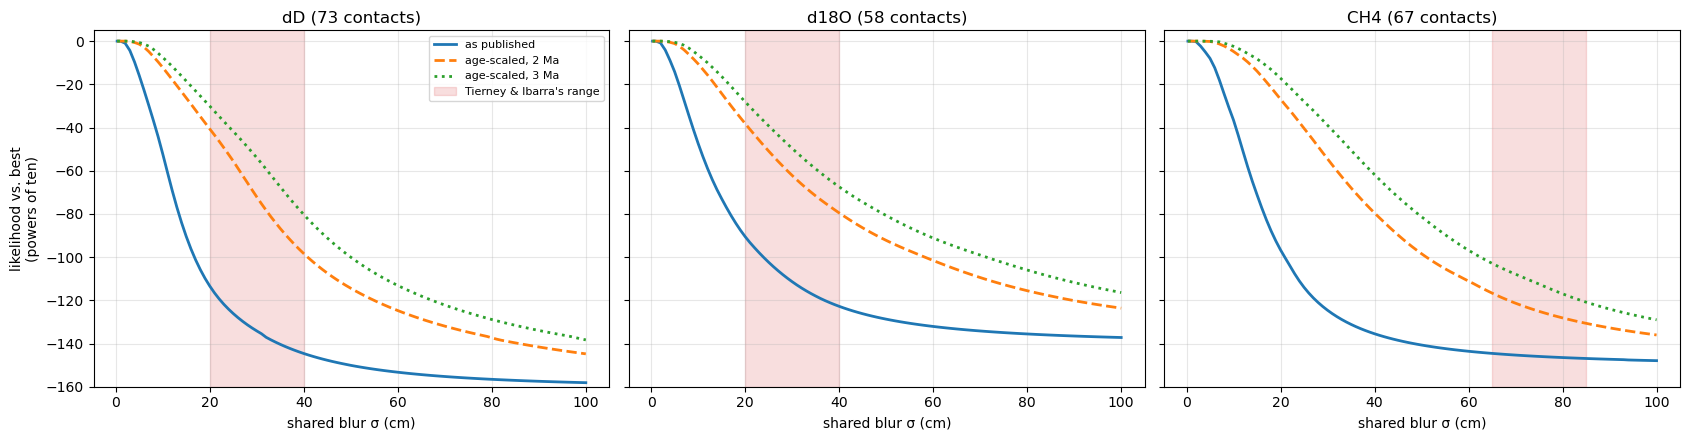

In [18]:
# For each proxy: how much less likely each shared sigma is than the best one, in
# powers of ten (0 = best, -10 = 10^10 times less likely). Tierney's range is shaded.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for a, var in zip(axes, ['dD', 'd18O', 'CH4']):
    sub = lik[lik['var'] == var]
    for label, ref_age, style in [('as published', None, '-'), ('age-scaled, 2 Ma', 2000, '--'),
                                  ('age-scaled, 3 Ma', 3000, ':')]:
        total = combined_evidence(sub, ref_age)
        a.plot(WIDTHS_TO_TRY * 100, (total - total.max()) / np.log(10), style, lw=2, label=label)
    lo, hi = TIERNEY_RANGE[var]
    a.axvspan(lo * 100, hi * 100, color='C3', alpha=0.15, label="Tierney & Ibarra's range")
    a.set_title(f'{var} ({len(sub)} contacts)')
    a.set_xlabel('shared blur σ (cm)'); a.set_ylim(-160, 5); a.grid(alpha=0.3)
axes[0].set_ylabel('likelihood vs. best\n(powers of ten)')
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


In [19]:
# Deliberately cherry-pick in Tierney & Ibarra's favour: keep only the widest half or
# quarter of contacts, in case a few misleadingly sharp "contacts" (e.g. noise spikes)
# drive the result.
rows = []
for var in ['dD', 'd18O', 'CH4']:
    sub = lik[lik['var'] == var]
    for keep_label, keep_frac in [('all contacts', 0.0), ('widest half', 0.5), ('widest quarter', 0.75)]:
        kept = sub[sub.sigma >= sub.sigma.quantile(keep_frac)] if keep_frac else sub
        row = {'proxy': var, 'contacts used': f'{keep_label} ({len(kept)})'}
        for label, ref_age in [('as published', None), ('age-scaled 2 Ma', 2000), ('age-scaled 3 Ma', 3000)]:
            log10_odds, p = probability_tierney(combined_evidence(kept, ref_age), TIERNEY_RANGE[var])
            row[label] = f'{p:.2g}  (odds 10^{int(round(log10_odds))})'
        rows.append(row)
print('P(Tierney | data), starting from 50/50:')
pd.DataFrame(rows)


P(Tierney | data), starting from 50/50:


,proxy,contacts used,as published,age-scaled 2 Ma,age-scaled 3 Ma
0,dD,all contacts (73),9.2e-114 (odds 10^-113),2.8e-41 (odds 10^-41),8.8e-31 (odds 10^-30)
1,dD,widest half (37),1.9e-49 (odds 10^-49),0.00032 (odds 10^-3),0.063 (odds 10^-1)
2,dD,widest quarter (19),8.2e-15 (odds 10^-14),0.53 (odds 10^0),0.64 (odds 10^0)
3,d18O,all contacts (58),7.1e-91 (odds 10^-90),8.3e-39 (odds 10^-38),8.9e-29 (odds 10^-28)
4,d18O,widest half (29),4e-25 (odds 10^-24),0.0058 (odds 10^-2),0.096 (odds 10^-1)
5,d18O,widest quarter (15),1.4e-05 (odds 10^-5),0.49 (odds 10^0),0.6 (odds 10^0)
6,CH4,all contacts (67),1.6e-144 (odds 10^-144),2.1e-117 (odds 10^-117),9.8e-104 (odds 10^-103)
7,CH4,widest half (34),2.2e-83 (odds 10^-83),1.2e-61 (odds 10^-61),5.2e-51 (odds 10^-50)
8,CH4,widest quarter (17),2e-32 (odds 10^-32),1.1e-19 (odds 10^-19),6.1e-14 (odds 10^-13)


In [20]:
# Resample contacts with replacement 300 times and recompute the odds (as published).
# If a handful of contacts were doing all the work, some resamples would miss them
# and the odds would swing a lot.
rng = np.random.default_rng(1)
rows = []
for var in ['dD', 'd18O', 'CH4']:
    sub = lik[lik['var'] == var].reset_index(drop=True)
    odds = [probability_tierney(combined_evidence(sub.iloc[rng.integers(0, len(sub), len(sub))]),
                                TIERNEY_RANGE[var])[0] for _ in range(300)]
    rows.append({'proxy': var,
                 'log10 odds, typical resample': np.median(odds),
                 'most favourable 5% of resamples': np.percentile(odds, 95),
                 'single most favourable resample': np.max(odds)})
pd.DataFrame(rows).round(0)


,proxy,"log10 odds, typical resample",most favourable 5% of resamples,single most favourable resample
0,dD,-111.0,-89.0,-75.0
1,d18O,-90.0,-72.0,-61.0
2,CH4,-144.0,-116.0,-97.0
